# Gradient Boosting

            ## 1. Learning objectives

            - Connect residual fitting to derivatives and gradients
- Implement regression boosting with stumps
- Tune learning rate and stage count jointly

            ## 2. Prerequisites

            Basic Python, NumPy arrays, means, and the supervised-learning overview.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Build a strong predictor by sequentially correcting errors from an existing ensemble.

            ## 4. Real-world use cases

            - Risk classification
- Demand prediction
- Decision-support ranking

            ## 5. Core intuition in simple language

            Each new weak learner focuses on what the current ensemble still gets wrong, then contributes a small correction.

## 6. Mathematical foundation

            $$F_m(\mathbf x)=F_{m-1}(\mathbf x)+\eta h_m(\mathbf x),\qquad h_m\approx-\frac{\partial L(y,F)}{\partial F}\bigg|_{F=F_{m-1}}.$$

            **Every symbol:**

            - $F_m$ is ensemble after stage m.
- $h_m$ is new weak learner.
- $\eta$ is learning rate.
- $L$ is loss.
- $-\partial L/\partial F$ is the negative functional gradient.

            **Why the equation is needed:** It views boosting as optimization in function space; for squared error the negative gradient is proportional to the residual.

            **Small numerical example:** If current prediction is 6, true target 10, stump predicts residual 3, and eta=.1, new prediction is 6.3.

            **Connection to Python:** residual = y - prediction; prediction += learning_rate * stump.predict(X).

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Define target and success metric
2. Split observations before fitted preprocessing
3. Build a simple baseline
4. Fit a transparent implementation
5. Fit the library estimator
6. Tune with validation evidence
7. Evaluate once on untouched test data

## 9. Implementation from scratch

A readable NumPy version exposes the mechanism and is checked against a tiny hand calculation.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
class RegressionStump:
    def fit(self,features,target):
        best=(np.inf,None,None,None,None)
        for feature in range(features.shape[1]):
            for threshold in np.unique(features[:,feature]):
                left=features[:,feature]<=threshold
                if left.all() or (~left).all(): continue
                left_value=target[left].mean(); right_value=target[~left].mean()
                prediction=np.where(left,left_value,right_value)
                error=np.mean((target-prediction)**2)
                if error<best[0]: best=(error,feature,threshold,left_value,right_value)
        _,self.feature_,self.threshold_,self.left_value_,self.right_value_=best
        return self
    def predict(self,features):
        return np.where(features[:,self.feature_]<=self.threshold_,self.left_value_,self.right_value_)

class GradientBoostingScratch:
    def __init__(self,n_estimators=40,learning_rate=.1):
        self.n_estimators=n_estimators; self.learning_rate=learning_rate
    def fit(self,features,target):
        self.initial_=target.mean(); prediction=np.full(len(target),self.initial_); self.models_=[]; self.losses_=[]
        for _ in range(self.n_estimators):
            residual=target-prediction
            stump=RegressionStump().fit(features,residual)
            prediction+=self.learning_rate*stump.predict(features)
            self.models_.append(stump); self.losses_.append(np.mean((target-prediction)**2))
        return self
    def predict(self,features):
        prediction=np.full(len(features),self.initial_)
        for stump in self.models_: prediction+=self.learning_rate*stump.predict(features)
        return prediction

print("Negative MSE gradient is proportional to residual y-prediction.")

Negative MSE gradient is proportional to residual y-prediction.


## 10. Implementation using a standard library

Scikit-learn adds efficient numerical routines, validation, pipelines, and model-selection compatibility.

## 11. Dataset loading and exploration

The lesson uses a bundled or generated scikit-learn dataset with a fixed seed and no network access.

## 12. Data preprocessing

Train/validation/test roles are separated before scaling or other fitted transformations to prevent data leakage.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

,model,MAE,RMSE,R2
0,Mean baseline,65.527,74.881,-0.014
1,Scratch boosting,42.775,53.121,0.490
2,scikit-learn boosting,42.650,53.888,0.475


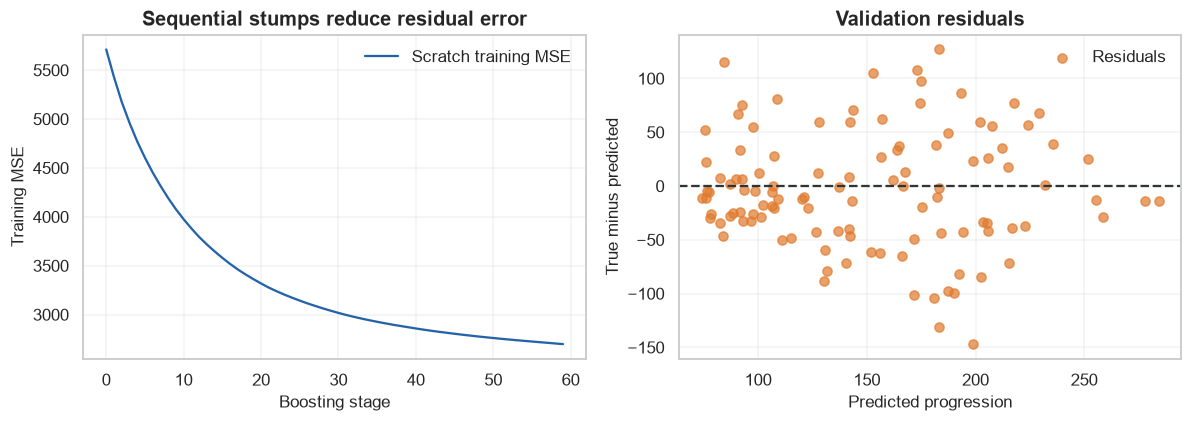

In [3]:
from sklearn.datasets import load_diabetes
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.model_selection import train_test_split

data=load_diabetes()
X_train,X_validation,y_train,y_validation=train_test_split(data.data,y:=data.target,test_size=.25,random_state=RANDOM_SEED)
scratch=GradientBoostingScratch(n_estimators=60,learning_rate=.1).fit(X_train,y_train)
library=GradientBoostingRegressor(n_estimators=100,learning_rate=.05,max_depth=2,random_state=RANDOM_SEED).fit(X_train,y_train)
rows=[]
for name,prediction in [("Mean baseline",np.full(len(y_validation),y_train.mean())),("Scratch boosting",scratch.predict(X_validation)),("scikit-learn boosting",library.predict(X_validation))]:
    rows.append({"model":name,"MAE":mean_absolute_error(y_validation,prediction),"RMSE":mean_squared_error(y_validation,prediction)**.5,"R2":r2_score(y_validation,prediction)})
comparison=pd.DataFrame(rows); display(comparison.round(3))
library_prediction=library.predict(X_validation)
figure,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].plot(scratch.losses_,color=COURSE_COLORS["blue"],label="Scratch training MSE"); axes[0].set(title="Sequential stumps reduce residual error",xlabel="Boosting stage",ylabel="Training MSE"); axes[0].legend()
axes[1].scatter(library_prediction,y_validation-library_prediction,color=COURSE_COLORS["orange"],alpha=.7,label="Residuals"); axes[1].axhline(0,color=COURSE_COLORS["charcoal"],linestyle="--"); axes[1].set(title="Validation residuals",xlabel="Predicted progression",ylabel="True minus predicted"); axes[1].legend()
figure.tight_layout(); plt.show()

**How to interpret the result:** Falling scratch loss shows sequential correction. Residual structure reveals remaining bias that a single RMSE cannot show.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

Small learning rates usually need more stages; too many high-rate stages can overfit. Tune the pair together.

,learning_rate,estimators,validation_RMSE
0,0.02,30,62.32
1,0.02,80,55.95
2,0.02,160,54.04
3,0.05,30,56.14
4,0.05,80,53.84
5,0.05,160,55.13
6,0.10,30,53.92
7,0.10,80,54.77
8,0.10,160,56.14
9,0.20,30,54.32


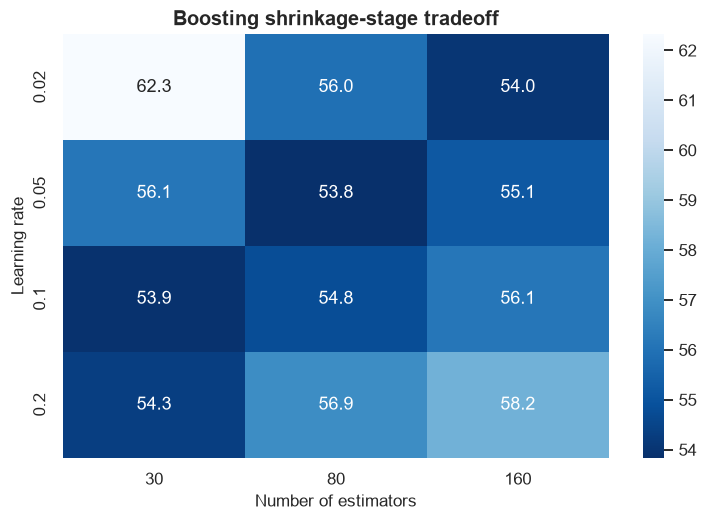

In [4]:
rows=[]
for rate in [.02,.05,.1,.2]:
    for estimators in [30,80,160]:
        candidate=GradientBoostingRegressor(learning_rate=rate,n_estimators=estimators,max_depth=2,random_state=RANDOM_SEED).fit(X_train,y_train)
        rows.append({"learning_rate":rate,"estimators":estimators,"validation_RMSE":mean_squared_error(y_validation,candidate.predict(X_validation))**.5})
tuning=pd.DataFrame(rows); display(tuning.round(2))
pivot=tuning.pivot(index="learning_rate",columns="estimators",values="validation_RMSE")
figure,axis=plt.subplots(); sns.heatmap(pivot,annot=True,fmt=".1f",cmap="Blues_r",ax=axis); axis.set(title="Boosting shrinkage-stage tradeoff",xlabel="Number of estimators",ylabel="Learning rate"); plt.show()

## 18. Common mistakes

            - Fitting preprocessing before splitting
- Selecting hyperparameters on test data
- Reporting one metric without a baseline
- Confusing predictive association with causation

            ## 19. Advantages and disadvantages

            **Advantages**

            - Direct objective from labeled examples
- Clear held-out evaluation

            **Disadvantages**

            - Sequential training is less parallel than random forests
- Sensitive to interacting hyperparameters
- Can overfit noisy targets

            ## 20. When to use and when not to use the algorithm

            **Use it when:** a trustworthy target represents the decision and representative labeled examples are available.

            **Do not use it when:** labels do not represent the desired outcome or the goal is causal intervention rather than prediction.

## 21. Exercises

1. **Conceptual:** Why must the test set remain untouched during selection?
2. **Mathematical/hand calculation:** Calculate the displayed equation on a small example.
3. **Coding/experimentation:** Change one hyperparameter and explain training-versus-validation behavior.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. Repeated test feedback leaks selection information and makes final performance optimistic.
2. Substitute each number, compute in the displayed order, and retain units.
3. Keep the split fixed, retrain each candidate, and prefer stable validation evidence rather than the best training score.

</details>

## 23. Summary and key takeaways

            - Data splitting and preprocessing are part of the model
- Scratch code explains the mechanism while the library version supports realistic use
- Metrics must match error costs
- Generalization—not memorization—is the objective

            ## 24. Further reading

            - [scikit-learn supervised learning guide](https://scikit-learn.org/stable/supervised_learning.html)
- [scikit-learn common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html)